##  🏠 House Price Prediction using Multiple Linear Regression

I recently worked on a House Price Prediction problem using a Multiple Linear Regression model.

🎯 Problem Statement

The goal was to predict the price of a house based on different features such as:

• Area
• Bedrooms & Bathrooms
• Stories
• Parking
• Main Road
• Guest Room
• Basement
• Air Conditioning
• Furnishing Status
• Preferred Area

In [ ]:
#Importing libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 

EDA - Exploratory Data Analysis

In [2]:
r = "D:\House Prediction Model\Dataset\Housing.csv"
dataset = pd.read_csv(r)
dataset.head(5)


<>:1: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
<>:1: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
C:\Users\hamza\AppData\Local\Temp\ipykernel_25428\2567361754.py:1: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
  r = "D:\House Prediction Model\Dataset\Housing.csv"


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
#Checking dataset shape No. of Columns and No. of Rows
print(f"Dataset:\n{dataset.shape}")

#Checking data information and its data types
print(dataset.info())

Dataset:
(545, 13)
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB
None


In [4]:
#Looking for a missing Values
dataset.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [5]:
dataset.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
dataset.duplicated().sum()

np.int64(0)

In [7]:
dataset["furnishingstatus"].unique()

<StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str

In [8]:
dataset.describe(include="O")

C:\Users\hamza\AppData\Local\Temp\ipykernel_25428\3312066537.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dataset.describe(include="O")


,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


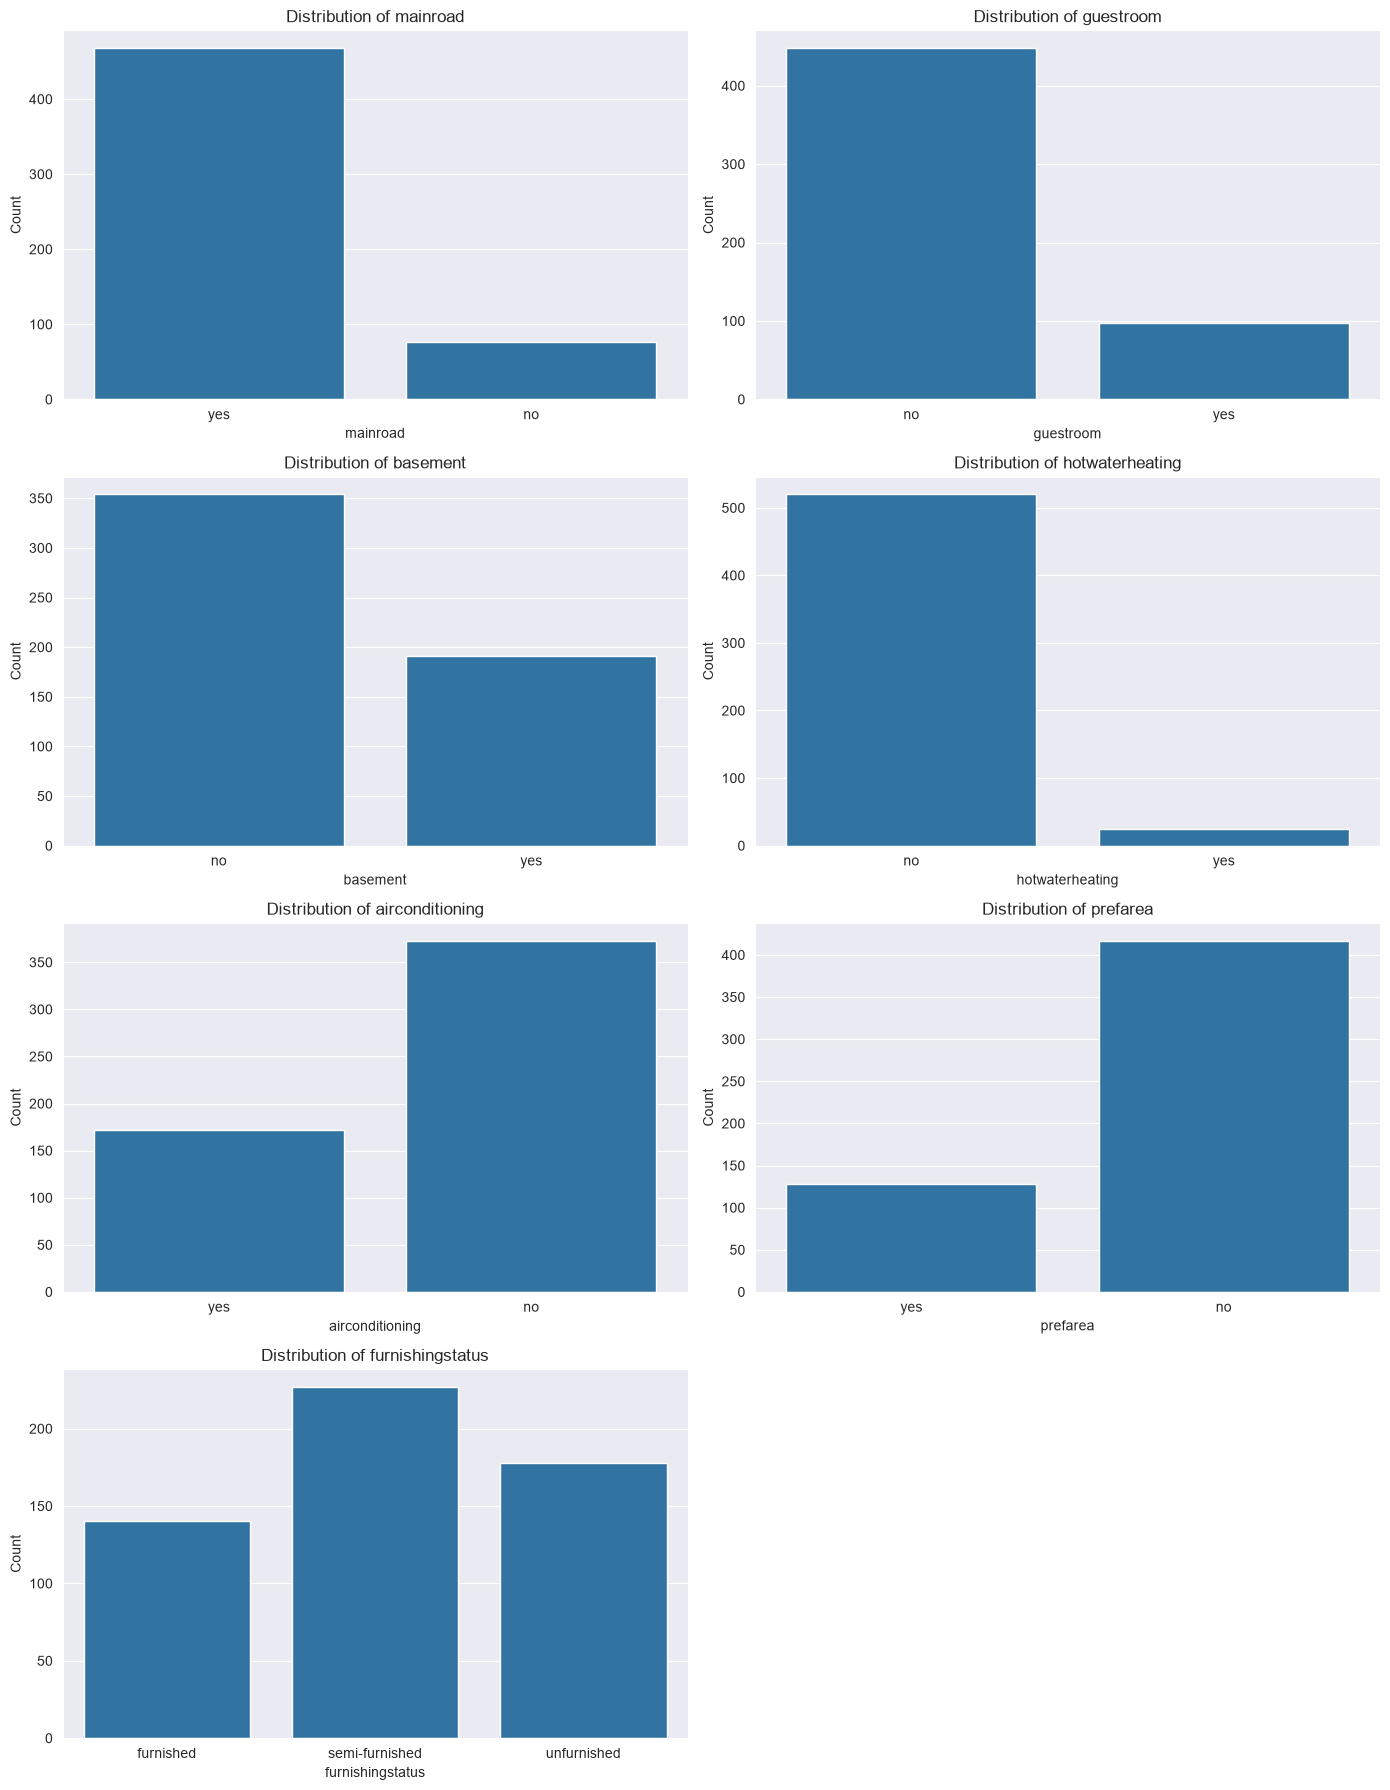

In [9]:
sns.set_style("darkgrid")

categorical_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus"
]

plt.figure(figsize=(14, 18))

for idx, feature in enumerate(categorical_columns, 1):
    plt.subplot(4, 2, idx)
    sns.countplot(data=dataset, x=feature)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [10]:
# Here converting categorial values yes and no into 0 and 1 

cols = ['mainroad' , 'guestroom' , 'basement' , 'hotwaterheating' , 'airconditioning' , 'prefarea']
dataset[cols] = dataset[cols].apply(lambda x: x.map({"yes" : 1 , "no" :  0}))

In [11]:
dataset = pd.get_dummies(dataset, columns=['furnishingstatus'], drop_first=True)

In [12]:
dataset.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.858716,0.177982,0.350459,0.045872,0.315596,0.693578,0.234862
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000


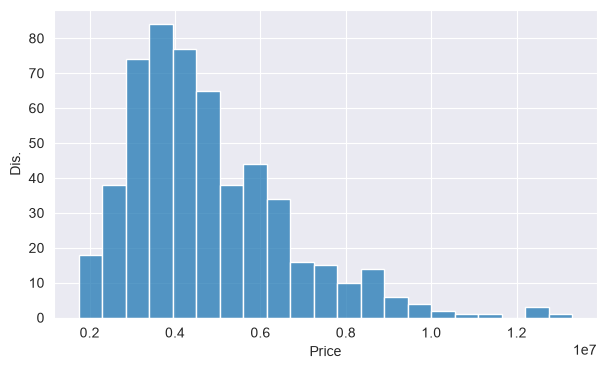

In [13]:
plt.figure(figsize = (7,4))
sns.histplot(dataset, x = "price")
plt.xlabel("Price")
plt.ylabel("Dis.")
plt.show()

In [14]:
fig = px.box(dataset , x="price" , title="Dis OF Price")
fig.show()


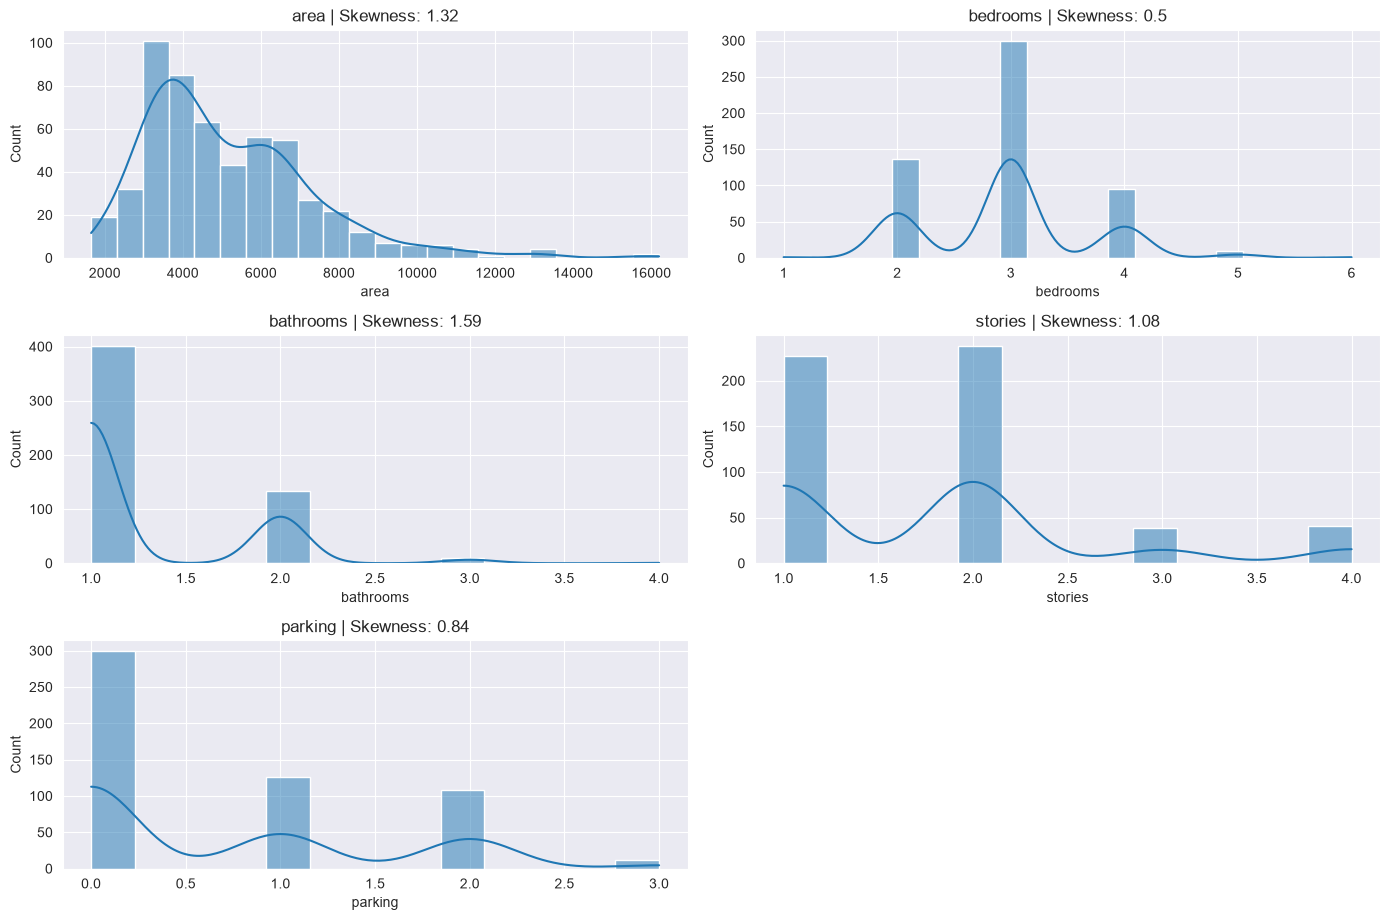

In [15]:
sns.set_style("darkgrid")

numerical_columns = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

plt.figure(figsize=(14, len(numerical_columns) * 3))

for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(dataset[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(dataset[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

In [16]:
X = dataset.drop("price", axis=1).values
y = dataset[["price"]].values

In [17]:
X

array([[7420, 4, 2, ..., 1, False, False],
       [8960, 4, 4, ..., 0, False, False],
       [9960, 3, 2, ..., 1, True, False],
       ...,
       [3620, 2, 1, ..., 0, False, True],
       [2910, 3, 1, ..., 0, False, False],
       [3850, 3, 1, ..., 0, False, True]], shape=(545, 13), dtype=object)

In [18]:
y

array([[13300000],
       [12250000],
       [12250000],
       [12215000],
       [11410000],
       [10850000],
       [10150000],
       [10150000],
       [ 9870000],
       [ 9800000],
       [ 9800000],
       [ 9681000],
       [ 9310000],
       [ 9240000],
       [ 9240000],
       [ 9100000],
       [ 9100000],
       [ 8960000],
       [ 8890000],
       [ 8855000],
       [ 8750000],
       [ 8680000],
       [ 8645000],
       [ 8645000],
       [ 8575000],
       [ 8540000],
       [ 8463000],
       [ 8400000],
       [ 8400000],
       [ 8400000],
       [ 8400000],
       [ 8400000],
       [ 8295000],
       [ 8190000],
       [ 8120000],
       [ 8080940],
       [ 8043000],
       [ 7980000],
       [ 7962500],
       [ 7910000],
       [ 7875000],
       [ 7840000],
       [ 7700000],
       [ 7700000],
       [ 7560000],
       [ 7560000],
       [ 7525000],
       [ 7490000],
       [ 7455000],
       [ 7420000],
       [ 7420000],
       [ 7420000],
       [ 735

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) 

In [20]:
# # 2. Feature Engineering
# from sklearn.preprocessing import PolynomialFeatures
# poly = PolynomialFeatures(
#     degree=2,
#     include_bias=False
# )

# X_train = poly.fit_transform(X_train)
# X_test = poly.transform(X_test)

# from sklearn.preprocessing import KBinsDiscretizer

# kbins = KBinsDiscretizer(
#     n_bins=5,
#     encode="ordinal",
#     strategy="quantile"
# )

# X_train = kbins.fit_transform(X_train)
# X_test = kbins.transform(X_test)

In [21]:
from sklearn.preprocessing import RobustScaler


_Xscalar = RobustScaler()
_Yscalar = RobustScaler()


X_train = _Xscalar.fit_transform(X_train)
X_test = _Xscalar.transform(X_test)


y_train = _Yscalar.fit_transform(y_train)
y_test = _Yscalar.transform(y_test)

In [22]:
X_train

array([[ 0.54347826,  0.        ,  1.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.97826087,  0.        ,  1.        , ...,  0.        ,
         1.        ,  0.        ],
       [-0.24782609, -1.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.16666667, -1.        ,  0.        , ...,  0.        ,
         0.        ,  1.        ],
       [ 0.36231884,  0.        ,  1.        , ...,  0.        ,
         1.        ,  0.        ]], shape=(436, 13))

In [23]:
y_train

array([[ 1.53871774],
       [ 0.95587011],
       [-0.17651957],
       [-0.40965862],
       [-0.60949209],
       [ 0.15653622],
       [-1.20899251],
       [-0.60949209],
       [-0.84263114],
       [-0.2764363 ],
       [-0.27976686],
       [-0.87593672],
       [-0.04329725],
       [-0.30974188],
       [-0.30974188],
       [ 0.51956703],
       [-1.20083264],
       [ 0.45628643],
       [-0.37635304],
       [ 1.18900916],
       [-0.17651957],
       [-0.17651957],
       [ 0.72273106],
       [ 0.45628643],
       [ 0.78934221],
       [-0.37635304],
       [-0.89592007],
       [-0.77601998],
       [ 0.47293922],
       [-0.29308909],
       [-0.04329725],
       [-0.95920067],
       [-0.34304746],
       [ 0.15653622],
       [-0.04329725],
       [-0.57285595],
       [-0.49292256],
       [ 2.17152373],
       [-0.30974188],
       [ 1.45212323],
       [ 0.1898418 ],
       [ 0.00666112],
       [-0.30974188],
       [ 0.05328893],
       [-0.00999167],
       [-0

In [24]:
class MultipleLinearRegression():

    def __init__(self):
        self.coefficients = None
        self.intercept = None
        self.r2score = None

    def fit(self, X_train, y_train):

        # Number of training samples
        n = X_train.shape[0]

        # Add a column of 1s for the intercept
        x_b = np.c_[np.ones((n, 1)), X_train]

        # Calculate coefficients using pseudo-inverse
        self.coefficients = np.linalg.pinv(x_b).dot(y_train)

        # Get intercept
        self.intercept = self.coefficients[0]

        # Training predictions
        y_pred = x_b.dot(self.coefficients)

        # Calculate training R²
        self.r2score = 1 - (
            np.sum((y_train - y_pred) ** 2) /
            np.sum((y_train - np.mean(y_train)) ** 2)
        )

        # Store predictions
        self.y_pred = y_pred

    def predict(self, X_test):

        # Add a column of 1s for the intercept
        x_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

        # Return predictions
        return x_b.dot(self.coefficients)

In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
model = MultipleLinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)


test_r2 = r2_score(y_test, y_pred)
print("Testing R²:", test_r2)


print("Training R²:", model.r2score)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
# print("Coefficients:", model.coefficients)
print("Y-Intercept:", model.intercept)





Testing R²: 0.6529242642153172
Training R²: 0.6859438988560158
MAE: 0.4615408130939286
MSE: 0.3971425110262329
Y-Intercept: [-0.21955703]


## Now we will check Multiple Linear Regression With scikit-learn

In [26]:
from sklearn.linear_model import LinearRegression

mlr_model = LinearRegression()

mlr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 13)","[[ 0.31, 0.04, 0.52,..., 0.3 ,-0.06,-0.2 ]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-0.22]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[22.51,18.91,14.17,..., 6.41, 6. , 4.45]"


In [27]:
y_train_pred = mlr_model.predict(X_train)
y_test_pred = mlr_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)

Training R²: 0.6859438988560158
Testing R²: 0.6529242642153177
